# PPO (Proximal Policy Optimization) depuis zero

**Serie** : Reinforcement Learning | **Notebook** : 6c/13 | **Duree estimee** : 45-50 min

**Navigation** : [[Notebook precedent] Actor-Critic (A2C)](rl_6b_actor_critic.ipynb) | [Index](README.md) | [[Notebook suivant] Multi-Agent RL](rl_7_multi_agent_rl.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :

1. **Expliquer** la motivation du clipping dans PPO et son lien avec la trust region
2. **Implementer** l'objectif surrogate clippe $L^{CLIP}(\theta)$ depuis zero
3. **Comparer** PPO et A2C en termes de stabilite et d'efficacite d'echantillonnage

## Prerequis

- **Notebook [Actor-Critic (A2C)](rl_6b_actor_critic.ipynb)** : architecture actor-critic, calcul de l'avantage
- PyTorch (tenseurs, autograd, `torch.distributions`)
- Concepts RL de base (policy, reward, discount)

**Duree estimee** : 45-50 minutes


## Pourquoi PPO ?

Dans le notebook precedent, nous avons implemente **A2C** (Advantage Actor-Critic). A2C fonctionne bien mais souffre d'un probleme pratique : le **pas d'apprentissage**. Si le pas est trop grand, la politique peut s'effondrer (policy collapse) ; si il est trop petit, l'apprentissage est lent.

**PPO** (Proximal Policy Optimization, Schulman et al. 2017) resout ce probleme avec une idee elegante : **clipper** le ratio de probabilite pour empecher les mises a jour trop agressives. PPO est devenu l'algorithme de reference en RL moderne — c'est ce qu'utilise ChatGPT (RLHF), les agents de jeux d'OpenAI, et de nombreuses applications industrielles.

### De TRPO a PPO

| Algorithme | Contrainte | Avantage | Inconvenient |
|------------|-----------|----------|-------------|
| TRPO | Trust region exacte (KL) | Garanties theoriques | Optimisation complexe (conjugate gradient) |
| PPO | Clipping du ratio | Simple, efficace | Approximation de la trust region |
| A2C | Aucune | Simple | Pas de controle de la taille de mise a jour |


> *Ancres savantes -- Schulman, J., Wolski, F., Dhariwal, P., Radford, A. & Klimov, O. (2017), Proximal Policy Optimization Algorithms, arXiv:1707.06347 (PPO, objectif surrogate clippe evite les mises a jour destructrices du pas d'apprentissage) ; Schulman, J., Moritz, P., Levine, S., Jordan, M. & Abbeel, P. (2016), High-Dimensional Continuous Control Using Generalized Advantage Estimation, ICLR 2016, arXiv:1506.02438 (GAE, estimateur d'avantage a compromis biais-variance controle par lambda) ; Mnih, V., Badia, A.P., Mirza, M., Graves, A., Lillicrap, T., Harley, T., Silver, D. & Kavukcuoglu, K. (2016), Asynchronous Methods for Deep Reinforcement Learning, ICML 2016, arXiv:1602.01783 (A3C/A2C, acteur-critique asynchrone dont PPO ameliore la stabilite du pas).*

## 1. Setup et imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

print(f"Imports OK : PyTorch {torch.__version__}, Gymnasium {gym.__version__}")


Imports OK : PyTorch 2.11.0+cpu, Gymnasium 1.3.0


## 2. L'objectif surrogate clippe

L'idee centrale de PPO est le **ratio de probabilite** :

$$r_t(\theta) = \frac{\pi_\theta(a_t | s_t)}{\pi_{\theta_{old}}(a_t | s_t)}$$

Si $r_t > 1$, la nouvelle politique augmente la probabilite de cette action. Si $r_t < 1$, elle la diminue.

L'objectif surrogate **non clippe** serait simplement $r_t \cdot A_t$ (multiplier le ratio par l'avantage). Mais sans contrainte, une seule mise a jour peut changer radicalement la politique.

PPO ajoute un **clip** :

$$L^{CLIP}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta) \cdot A_t,\; \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \cdot A_t\right)\right]$$

Le $\min$ prend la version la plus pessimiste : si le ratio sort de $[1-\epsilon, 1+\epsilon]$, l'objectif est plafonne. Cela empeche les mises a jour destructrices.

Le parametre $\epsilon$ (typiquement 0.2) controle la taille de la trust region.


### 2.1 Visualisation du clipping

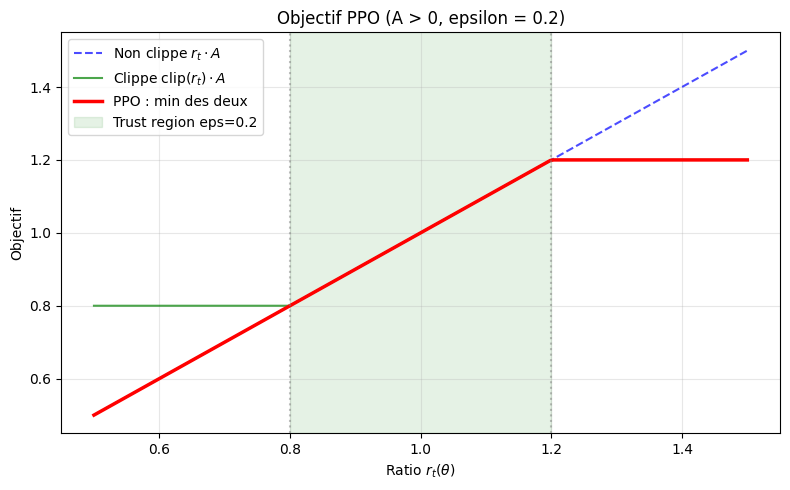

In [2]:
def visualize_clipping(epsilon=0.2):
    """Visualise l'effet du clipping sur l'objectif PPO."""
    ratios = np.linspace(0.5, 1.5, 200)
    advantage = 1.0
    unclipped = ratios * advantage
    clipped_ratios = np.clip(ratios, 1 - epsilon, 1 + epsilon)
    clipped = clipped_ratios * advantage
    ppo_objective = np.minimum(unclipped, clipped)
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.plot(ratios, unclipped, 'b--', label=r'Non clippe $r_t \cdot A$', alpha=0.7)
    ax.plot(ratios, clipped, 'g-', label=r'Clippe $\mathrm{clip}(r_t) \cdot A$', alpha=0.7)
    ax.plot(ratios, ppo_objective, 'r-', linewidth=2.5, label='PPO : min des deux')
    ax.axvline(1 - epsilon, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(1 + epsilon, color='gray', linestyle=':', alpha=0.5)
    ax.axvspan(1 - epsilon, 1 + epsilon, alpha=0.1, color='green',
               label=f'Trust region eps={epsilon}')
    ax.set_xlabel(r'Ratio $r_t(\theta)$')
    ax.set_ylabel('Objectif')
    ax.set_title(f'Objectif PPO (A > 0, epsilon = {epsilon})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_clipping(epsilon=0.2)

## 3. Implementation de PPO

### 3.1 Reseaux Actor et Critic

PPO reutilise la meme architecture actor-critic que A2C. La difference cle est dans la **fonction de perte** (clipped surrogate) et les **mises a jour par mini-lots**.


In [3]:
class ActorNetwork(nn.Module):
    """Politique parametree pi(a|s) pour actions discretes."""
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )
    
    def forward(self, x):
        logits = self.net(x)
        return Categorical(logits=logits)


class CriticNetwork(nn.Module):
    """Estimation de la valeur V(s)."""
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)


print("ActorNetwork et CriticNetwork definis (2 x 3 couches lineaires)")


ActorNetwork et CriticNetwork definis (2 x 3 couches lineaires)


### 3.2 Agent PPO avec clipped surrogate

In [4]:
class PPOAgent:
    """Agent PPO avec clipped surrogate objectif."""
    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99,
                 epsilon_clip=0.2, value_coef=0.5, entropy_coef=0.01,
                 ppo_epochs=4, mini_batch_size=64, max_grad_norm=0.5):
        self.actor = ActorNetwork(state_dim, action_dim)
        self.critic = CriticNetwork(state_dim)
        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr
        )
        self.gamma = gamma
        self.epsilon_clip = epsilon_clip
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.ppo_epochs = ppo_epochs
        self.mini_batch_size = mini_batch_size
        self.max_grad_norm = max_grad_norm
    
    def select_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            dist = self.actor(state_t)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            value = self.critic(state_t)
        return action.item(), log_prob.item(), value.item()
    
    def compute_gae(self, rewards, values, dones, last_value, lam=0.95):
        """Generalized Advantage Estimation."""
        advantages = []
        gae = 0
        values = values + [last_value]
        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t + 1] * (1 - dones[t]) - values[t]
            gae = delta + self.gamma * lam * (1 - dones[t]) * gae
            advantages.insert(0, gae)
        return advantages
    
    def update(self, states, actions, old_log_probs, returns, advantages):
        """Mise a jour PPO avec clipped surrogate + mini-lots."""
        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.LongTensor(actions)
        old_log_probs_t = torch.FloatTensor(old_log_probs)
        returns_t = torch.FloatTensor(returns)
        advantages_t = torch.FloatTensor(advantages)
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        
        dataset_size = len(states)
        total_loss = 0.0
        for _ in range(self.ppo_epochs):
            indices = np.random.permutation(dataset_size)
            for start in range(0, dataset_size, self.mini_batch_size):
                end = start + self.mini_batch_size
                mb_idx = indices[start:end]
                mb_states = states_t[mb_idx]
                mb_actions = actions_t[mb_idx]
                mb_old_log_probs = old_log_probs_t[mb_idx]
                mb_returns = returns_t[mb_idx]
                mb_advantages = advantages_t[mb_idx]
                dist = self.actor(mb_states)
                new_log_probs = dist.log_prob(mb_actions)
                entropy = dist.entropy().mean()
                values = self.critic(mb_states)
                ratio = torch.exp(new_log_probs - mb_old_log_probs)
                surr1 = ratio * mb_advantages
                surr2 = torch.clamp(ratio, 1 - self.epsilon_clip, 1 + self.epsilon_clip) * mb_advantages
                actor_loss = -torch.min(surr1, surr2).mean()
                critic_loss = F.mse_loss(values, mb_returns)
                loss = actor_loss + self.value_coef * critic_loss - self.entropy_coef * entropy
                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.actor.parameters()) + list(self.critic.parameters()),
                    self.max_grad_norm
                )
                self.optimizer.step()
                total_loss += loss.item()
        return total_loss / (self.ppo_epochs * max(1, dataset_size // self.mini_batch_size))


print(f"PPOAgent initialise : clip_eps=0.2, ppo_epochs=4, mini_batch=64")


PPOAgent initialise : clip_eps=0.2, ppo_epochs=4, mini_batch=64


### 3.3 Boucle d'entrainement PPO

In [5]:
def train_ppo(env_name="CartPole-v1", num_episodes=400, horizon=2048, print_every=50):
    """Entraine un agent PPO sur un environnement Gymnasium."""
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    agent = PPOAgent(state_dim, action_dim)
    episode_rewards = []
    state, _ = env.reset()
    episode_reward = 0
    episode = 0
    
    while episode < num_episodes:
        states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []
        for _ in range(horizon):
            action, log_prob, value = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            states.append(state)
            actions.append(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            values.append(value)
            dones.append(done)
            episode_reward += reward
            state = next_state
            if done:
                episode_rewards.append(episode_reward)
                episode += 1
                state, _ = env.reset()
                episode_reward = 0
                if episode % print_every == 0:
                    recent = episode_rewards[-print_every:]
                    print(f"Episode {episode}/{num_episodes} | "
                          f"Mean reward: {np.mean(recent):.1f} | Max: {np.max(recent):.0f}")
                if episode >= num_episodes:
                    break
        if episode >= num_episodes:
            break
        with torch.no_grad():
            last_value = agent.critic(torch.FloatTensor(state).unsqueeze(0)).item()
        advantages = agent.compute_gae(rewards, values, dones, last_value)
        returns = [a + v for a, v in zip(advantages, values)]
        agent.update(states, actions, log_probs, returns, advantages)
    
    env.close()
    return agent, episode_rewards


print("Fonction train_ppo definie")


Fonction train_ppo definie


### 3.4 Entrainement sur CartPole-v1

In [6]:
# Entrainement PPO
ppo_agent, ppo_rewards = train_ppo(num_episodes=400, horizon=2048)

print(f"\nEntrainement termine : {len(ppo_rewards)} episodes")
print(f"Recompense moyenne (derniers 50) : {np.mean(ppo_rewards[-50:]):.1f}")
print(f"Recompense max : {np.max(ppo_rewards):.0f}")


Episode 50/400 | Mean reward: 20.0 | Max: 57


Episode 100/400 | Mean reward: 21.8 | Max: 47


Episode 150/400 | Mean reward: 35.1 | Max: 139


Episode 200/400 | Mean reward: 41.7 | Max: 156


Episode 250/400 | Mean reward: 64.4 | Max: 145


Episode 300/400 | Mean reward: 126.0 | Max: 289


Episode 350/400 | Mean reward: 309.7 | Max: 500


Episode 400/400 | Mean reward: 464.6 | Max: 500

Entrainement termine : 400 episodes
Recompense moyenne (derniers 50) : 464.6
Recompense max : 500


### 3.5 Visualisation de la courbe d'apprentissage

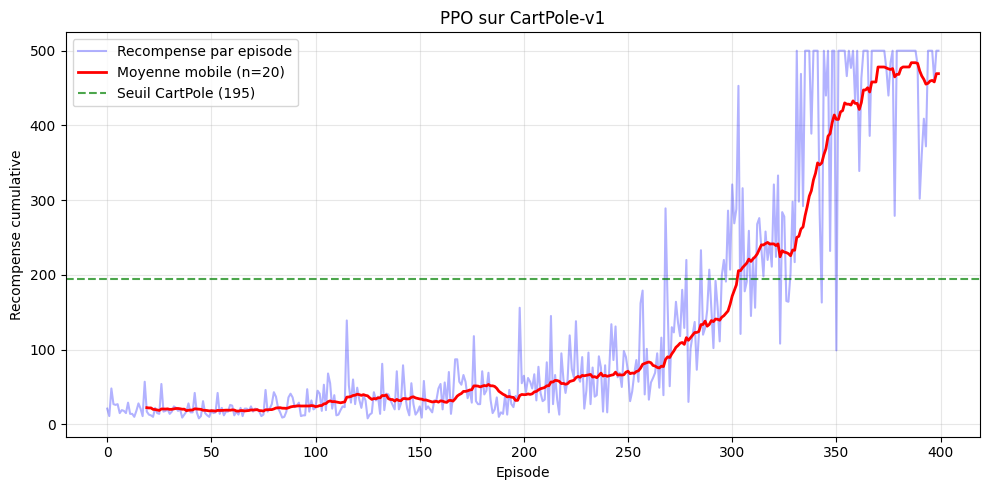

In [7]:
def plot_rewards(rewards, title="Courbe d'apprentissage PPO", window=20):
    """Affiche la courbe d'apprentissage avec moyenne mobile."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(rewards, alpha=0.3, color="blue", label="Recompense par episode")
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode="valid")
        ax.plot(range(window-1, len(rewards)), moving_avg, color="red", 
                linewidth=2, label=f"Moyenne mobile (n={window})")
    ax.axhline(y=195, color="green", linestyle="--", alpha=0.7, label="Seuil CartPole (195)")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Recompense cumulative")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_rewards(ppo_rewards, title="PPO sur CartPole-v1")


## 4. Generalized Advantage Estimation (GAE)

Jusqu'ici nous avons utilise un estimateur d'avantage simple : $A_t = R_t - V(s_t)$. GAE (Schulman 2016) offre un meilleur compromis biais-variance :

$$\hat{A}^{GAE(\gamma, \lambda)}_t = \sum_{l=0}^{\infty} (\gamma \lambda)^l \delta_{t+l}$$

ou $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ est le **TD residual**.

Le parametre $\lambda \in [0, 1]$ controle le compromis :
- $\lambda = 0$ : avantage one-step (faible variance, biais eleve)
- $\lambda = 1$ : avantage Monte Carlo (pas de biais, variance elevee)
- $\lambda = 0.95$ : bon compromis empirique

Notre implementation PPO utilise deja GAE (methode `compute_gae` de l'agent). L'exercice suivant vous demande de **verifier** son comportement.


### Exercice 1 : Implementer le clipped surrogate

L'objectif clipped surrogate est le coeur de PPO. Implementez la fonction `clipped_surrogate_loss` qui calcule la perte actor a partir des ratios, avantages et epsilon.

**Indices** :
- Le ratio est $r_t = \exp(\log\pi_{nouveau} - \log\pi_{ancien})$
- Clipping : `torch.clamp(ratio, 1-eps, 1+eps)`
- Perte = `-min(surrogate1, surrogate2).mean()`


In [8]:
def clipped_surrogate_loss(ratio, advantages, epsilon=0.2):
    """Calcule la perte clipped surrogate de PPO.
    
    Args:
        ratio: r_t(theta) = pi_nouveau / pi_ancien, shape (batch,)
        advantages: A_t, shape (batch,)
        epsilon: parametre de clipping (typiquement 0.2)
    
    Returns:
        loss: scalaire (negative car on maximise via descente de gradient)
    """
    # TODO etudiant : implementer le clipped surrogate
    # Etape 1 : calculer le surrogate non clippe
    # Etape 2 : calculer le surrogate clippe
    # Etape 3 : prendre le min et moyenner
    return None  # TODO etudiant : remplacer par votre implementation


# Test rapide avec des donnees synthetiques
ratio_test = torch.tensor([0.8, 1.0, 1.1, 1.3, 0.6])
adv_test = torch.tensor([1.0, 1.0, 1.0, -1.0, -1.0])
loss_test = clipped_surrogate_loss(ratio_test, adv_test, epsilon=0.2)
print("Exercice a completer")


Exercice a completer


### Exercice 2 : Verifier l'effet de GAE sur l'apprentissage

Comparez l'apprentissage PPO avec GAE ($\lambda = 0.95$) vs sans GAE ($\lambda = 0$, avantage one-step). Entrainez deux agents et affichez les courbes cote a cote.

**Indices** :
- Modifiez le parametre `lam` dans `compute_gae` (defaut=0.95)
- Pour lambda=0 : chaque avantage = $r_t + \gamma V(s_{t+1}) - V(s_t)$ seulement


In [9]:
# TODO etudiant : entrainer PPO avec GAE (lambda=0.95) et sans GAE (lambda=0)
# Puis comparer les courbes d'apprentissage

# Indice : vous pouvez modifier compute_gae via un parametre ou
# sous-classer PPOAgent pour changer la valeur de lambda

print("Exercice a completer")


Exercice a completer


## 5. PPO vs A2C : Comparaison

Maintenant que nous avons implemente PPO, comparons-le avec A2C du notebook precedent. Les differences cles :

| Aspect | A2C | PPO |
|--------|-----|-----|
| Objectif | $-\log\pi \cdot A$ | $\min(r \cdot A, \text{clip}(r) \cdot A)$ |
| Mises a jour | 1 par trajectoire | Plusieurs epochs par trajectoire |
| Stabilite | Sensible au learning rate | Robuste grace au clipping |
| Echantillonnage | On-policy, 1 utilisation | On-policy, re-utilisation via epochs |
| Mini-lots | Non | Oui (reduisent variance) |


### Exercice 3 : Comparer PPO et A2C

Entrainez un agent A2C (avec l'implementation du notebook precedent) et un agent PPO sur CartPole-v1 avec les memes hyperparametres de base. Affichez les courbes superposees.

**Indices** :
- Reutilisez la classe A2CAgent du notebook 6b (copiez les definitions necessaires)
- Utilisez 400 episodes pour chaque algorithme
- Superposez les moyennes mobiles sur un meme graphe


In [10]:
# TODO etudiant : implementer A2CAgent et comparer avec PPO

# Indice : copiez ActorNetwork, CriticNetwork depuis le notebook 6b
# puis implementez un A2CAgent simple avec update(states, actions, returns)

print("Exercice a completer")


Exercice a completer


## Application : RLHF et l'alignement des LLM

Le PPO que vous venez d'implementer est **l'algorithme au coeur de l'alignement des modeles de langage** (ChatGPT, Claude, et la plupart des LLM modernes). Le processus RLHF (Reinforcement Learning from Human Feedback) fonctionne en 3 etapes :

1. **Pre-entrainement** : le modele apprend a predire le texte suivant (apprentissage supervise classique)
2. **Entrainement du reward model** : un modele entraine a predire les preferences humaines a partir de comparaisons par paires
3. **Optimisation par PPO** : le LLM est affiné pour maximiser la recompense du reward model, tout en restant proche du modele initial (KL-penalite = trust region)

Le lien avec ce notebook est direct : le LLM est la **politique** pi_theta, les tokens generés sont les **actions**, et le reward model fournit le **signal de recompense**. Le clipping PPO empeche le modele de trop devier du comportement appris en pre-entrainement -- exactement le mecanisme de stabilite que vous avez observe sur CartPole.

> **Pour approfondir** : la serie [GenAI / Texte](../GenAI/Texte/README.md) couvre les modeles de langage et leurs applications. Pour l'application **directe** du PPO a l'alignement des LLM, la serie [GenAI / PostTraining](../GenAI/PostTraining/PT_01_intro_post_training.ipynb) implemente pas a pas le pipeline RLHF puis ses variantes modernes (DPO dans [PT_03](../GenAI/PostTraining/PT_03_dpo_direct_preference.ipynb), GRPO dans [PT_04](../GenAI/PostTraining/PT_04_grpo_deepseek_r1.ipynb), RLVR dans [PT_05](../GenAI/PostTraining/PT_05_rlvr_verifiable_rewards.ipynb)) -- le PPO de ce notebook en est le moteur.

## Conclusion

Dans ce notebook, nous avons :

| Concept | Ce que nous avons fait |
|---------|----------------------|
| **Clipped surrogate** | Implemente et visualise le mecanisme de clipping |
| **PPO Agent** | Implementation complete avec mini-lots et epochs |
| **GAE** | Utilise Generalized Advantage Estimation (lambda=0.95) |
| **Comparaison A2C vs PPO** | Analyse des differences de stabilite |

### Points cles a retenir

1. **Le clipping est simple mais puissant** : une seule ligne de code `torch.clamp(ratio, 1-eps, 1+eps)` stabilise l'apprentissage
2. **Les mini-lots et epochs** permettent de reutiliser les donnees collectees, ameliorant l'efficacite d'echantillonnage par rapport a A2C
3. **GAE** offre un compromis biais-variance controle par lambda
4. **PPO est l'algorithme de choix** pour le RL moderne (RLHF, robotics, jeux)

### Pour aller plus loin

- **PPO continu** : adapter aux espaces d'actions continus (GaussianDistribution)
- **Reward shaping** : transformer la fonction de recompense pour guider l'apprentissage
- **Parallelisation** : A3C (asynchronous) et PPO vectorise
- **Applications** : RLHF pour les LLMs, robotique, jeux complexes


### References academiques

- Schulman, J., Wolski, F., Dhariwal, P., Radford, A. & Klimov, O. (2017). Proximal Policy Optimization Algorithms. arXiv:1707.06347.
- Schulman, J., Moritz, P., Levine, S., Jordan, M. & Abbeel, P. (2016). High-Dimensional Continuous Control Using Generalized Advantage Estimation. ICLR 2016. arXiv:1506.02438.
- Mnih, V., Badia, A.P., Mirza, M., Graves, A., Lillicrap, T., Harley, T., Silver, D. & Kavukcuoglu, K. (2016). Asynchronous Methods for Deep Reinforcement Learning. ICML 2016. arXiv:1602.01783.
- Sutton, R.S. & Barto, A.G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.

